In [394]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [395]:
# load data
waterstress_data = pd.read_csv("data/AQUASTAT Dissemination System 1.csv")
waterstress_data.head()

,VariableGroup,Subgroup,Variable,Area,Year,Value,Unit,Symbol,IsAggregate
0,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2011,612.773225,current US$/inhab,X,False
1,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2012,649.710978,current US$/inhab,X,False
2,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2013,631.060444,current US$/inhab,X,False
3,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2014,596.048898,current US$/inhab,X,False
4,Geography and population,"Economy, development and food security",GDP per capita,Afghanistan,2015,554.004007,current US$/inhab,X,False


In [396]:
# look at data
print(waterstress_data['Area'].unique())
print(waterstress_data['Year'].unique())
print(waterstress_data['Variable'].unique())

['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia (Plurinational State of)'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei Darussalam'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus'
 'Czechia' "Côte d'Ivoire" "Democratic People's Republic of Korea"
 'Democratic Republic of the Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji' 'Finland' 'France'
 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada'
 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran (

In [397]:
# pivoting data to prepare for use
df_waterstress = waterstress_data.pivot_table(
    index=["Area", "Year"],
    columns="Variable",
    values="Value"
).reset_index()

df_waterstress.head(12)

Variable,Area,Year,Agricultural water withdrawal as % of total renewable water resources,GDP per capita,Population density,SDG 6.4.1. Water Use Efficiency,SDG 6.4.2. Water Stress,Total population
0,Afghanistan,2011,30.613807,612.773225,44.952529,0.679890,54.757019,29347.708
1,Afghanistan,2012,30.613807,649.710978,46.809475,0.738601,54.757019,30560.034
2,Afghanistan,2013,30.613807,631.060444,48.437190,0.804276,54.757019,31622.704
3,Afghanistan,2014,30.613807,596.048898,50.229028,0.877890,54.757019,32792.523
4,Afghanistan,2015,30.613807,554.004007,51.820856,0.886913,54.757019,33831.764
5,Afghanistan,2016,30.613807,526.164709,53.151689,0.761670,54.757019,34700.612
6,Afghanistan,2017,30.613807,534.020133,54.665526,0.774685,54.757019,35688.935
7,Afghanistan,2018,30.613807,513.981256,56.280120,0.803860,54.757019,36743.039
8,Afghanistan,2019,30.613807,512.910125,57.985052,0.876542,54.757019,37856.121
9,Afghanistan,2020,30.613807,512.749930,59.842813,0.835661,54.757019,39068.979


In [398]:
# List of countries from 'Area' to exclude
excluded_regions = ['World', 'Europe', 'Asia', 'High-income countries', 'Low-income countries','European Union (27)', 
                      'Least Developed Countries', 'Western Asia', 'Sub-Saharan Africa', 'Southern Asia', 'South-eastern Asia',
                      'Oceania', 'Oceania (excluding Australia and New Zealand)', 'Northern Africa','Northern Africa and Western Asia', 'Northern America', 'Latin America and the Caribbean',
                      'Land Locked Developing Countries', 'Europe and Northern America', 'Eastern Asia', 'Eastern and South-Eastern Asia', 
                      'Central Asia','Central and Southern Asia']
df_waterstress_clean = df_waterstress[~df_waterstress["Area"].isin(excluded_regions)]

In [399]:
# check missing values
print("\nMissing values per column:")
print(df_waterstress_clean.isnull().sum())

df_waterstress_clean.describe()



Missing values per column:
Variable
Area                                                                       0
Year                                                                       0
Agricultural water withdrawal as % of total renewable water resources    282
GDP per capita                                                            72
Population density                                                        24
SDG 6.4.1. Water Use Efficiency                                          396
SDG 6.4.2. Water Stress                                                  266
Total population                                                           0
dtype: int64


Variable,Year,Agricultural water withdrawal as % of total renewable water resources,GDP per capita,Population density,SDG 6.4.1. Water Use Efficiency,SDG 6.4.2. Water Stress,Total population
count,2422.000000,2140.000000,2350.000000,2398.000000,2026.000000,2156.000000,2.422000e+03
mean,2016.504542,53.486872,15752.347471,288.208199,45.183232,66.755322,3.803021e+04
std,3.450569,308.775980,26029.799998,1396.009805,107.978987,305.653618,1.429954e+05
min,2011.000000,0.000000,236.450173,1.755096,0.549735,0.027446,5.100000e-01
25%,2014.000000,0.431897,1966.500223,31.719719,6.035993,3.704729,1.540693e+03
50%,2017.000000,1.903915,5904.948748,81.963864,14.346732,10.810564,7.845068e+03
75%,2019.750000,13.560308,17504.061565,196.835040,44.868014,37.621471,2.799731e+04
max,2022.000000,3892.000000,240535.043309,18822.890972,1394.294841,3850.500000,1.458175e+06


In [400]:
# was initially trying something else,evaluating SDG measurements and nl data

# making sure 'Year' is an integer
df_waterstress_clean['Year'] = pd.to_numeric(df_waterstress_clean['Year'], errors='coerce')

# making sure 'Value' is numeric
df_waterstress_clean['SDG 6.4.2. Water Stress'] = pd.to_numeric(df_waterstress_clean['SDG 6.4.2. Water Stress'], errors='coerce')

water_stress_nl = df_waterstress_clean[(df_waterstress_clean['Area'] == 'Netherlands (Kingdom of the)')].copy()

# sort by year
water_stress_nl.sort_values(by='Year', inplace=True)

water_stress_nl.head(12)
             


/var/folders/4b/sly201491lz119kc400w1qrm0000gn/T/ipykernel_6657/2885858716.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/4b/sly201491lz119kc400w1qrm0000gn/T/ipykernel_6657/2885858716.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Variable,Area,Year,Agricultural water withdrawal as % of total renewable water resources,GDP per capita,Population density,SDG 6.4.1. Water Use Efficiency,SDG 6.4.2. Water Stress,Total population
1608,Netherlands (Kingdom of the),2011,0.131209,54132.113672,405.658570,61.200115,19.346877,16851.057
1609,Netherlands (Kingdom of the),2012,0.066154,49982.505941,407.202552,61.562017,20.346117,16915.194
1610,Netherlands (Kingdom of the),2013,0.117473,51989.400521,408.451204,66.555089,20.201253,16967.063
1611,Netherlands (Kingdom of the),2014,0.090879,52552.616156,409.968440,74.596901,18.017847,17030.089
1612,Netherlands (Kingdom of the),2015,0.116374,44906.997520,411.830356,80.570158,15.969242,17107.433
1613,Netherlands (Kingdom of the),2016,0.084066,45754.793012,414.171714,85.791540,15.233340,17204.693
1614,Netherlands (Kingdom of the),2017,0.131538,48460.512960,463.101631,89.527075,15.029808,17315.370
1615,Netherlands (Kingdom of the),2018,0.331978,52877.543522,465.934207,90.144370,16.366984,17421.280
1616,Netherlands (Kingdom of the),2019,0.278462,52420.699957,469.042712,88.114013,17.000607,17537.507
1617,Netherlands (Kingdom of the),2020,0.337582,52183.342924,471.696470,85.777689,16.803561,17636.731


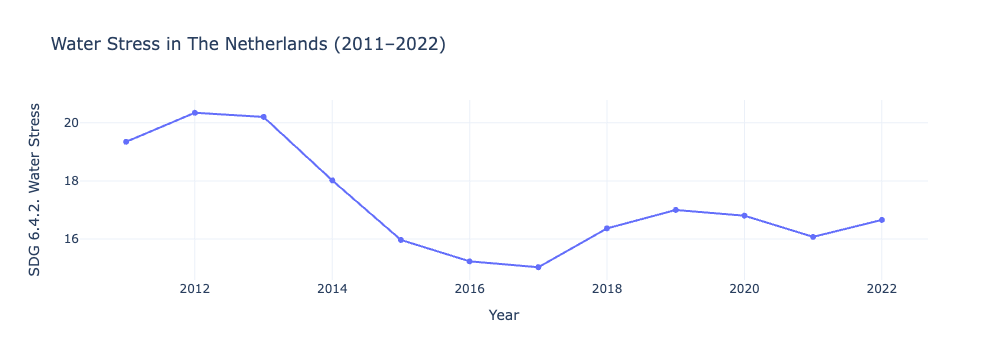

In [401]:
# visualization updated for The Netherlands Water Stress Through the Years
fig = px.line(
    water_stress_nl,
    x='Year',
    y='SDG 6.4.2. Water Stress',
    title='Water Stress in The Netherlands (2011–2022)',
    labels={'Value': 'Water Stress (%)'},
    markers=True
)

fig.update_layout(template='plotly_white')

#save as interactive HTML
fig.write_html("netherlands_water_stress_2011_2022.html")
fig.show()

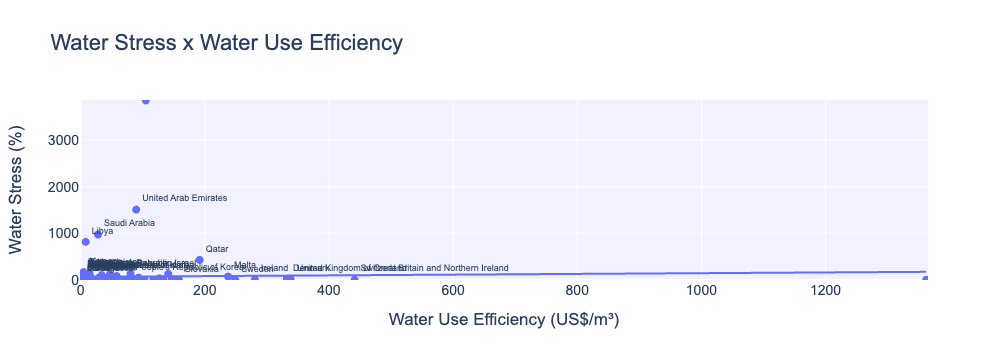

In [402]:
# visualization scatter 'water use efficiency' x 'water stress'
recent_year = df_waterstress_clean['Year'].max()
most_recent = df_waterstress_clean[df_waterstress_clean['Year'] == recent_year].copy()

# only label outliers (high water stress, very high/low water use efficiency)
high_stress = most_recent['SDG 6.4.2. Water Stress'] > 80
high_eff = most_recent['SDG 6.4.1. Water Use Efficiency'] > most_recent['SDG 6.4.1. Water Use Efficiency'].quantile(0.95)
low_eff = most_recent['SDG 6.4.1. Water Use Efficiency'] < most_recent['SDG 6.4.1. Water Use Efficiency'].quantile(0.05)

most_recent['Label'] = np.where(high_stress | high_eff | low_eff, most_recent['Area'], '')

fig = px.scatter(
    most_recent,
    x='SDG 6.4.1. Water Use Efficiency',
    y='SDG 6.4.2. Water Stress',
    text='Label', 
    trendline='ols',
    title='Water Stress x Water Use Efficiency',
    labels={
        'SDG 6.4.1. Water Use Efficiency': 'Water Use Efficiency (US$/m³)',
        'SDG 6.4.2. Water Stress': 'Water Stress (%)'
    },
)

fig.update_traces(
    textposition='top right',
    marker=dict(size=8),
    textfont=dict(size=9),
    hovertemplate='<b>%{text}</b><br>Water Stress: %{y}<br>Water Use Efficiency: %{US$/m³}<extra></extra>'
)

fig.update_layout(
    xaxis=dict(range=[-1, most_recent['SDG 6.4.1. Water Use Efficiency'].max() + 3]),
    yaxis=dict(range=[0, most_recent['SDG 6.4.2. Water Stress'].max() + 10]),
    plot_bgcolor='rgba(240,240,255,0.95)',
    title_font_size=22,
    font=dict(family="Arial", size=14)
)

fig.show()


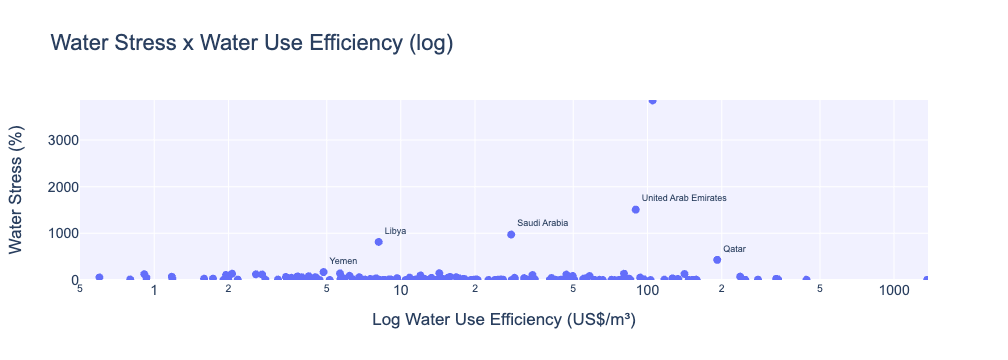

In [403]:
# visualization scatter 'water use efficiency' log scale x 'water stress' 
recent_year = df_waterstress_clean['Year'].max()
most_recent = df_waterstress_clean[df_waterstress_clean['Year'] == recent_year].copy()

# labelling certain outliers 
label_countries = ['United Arab Emirates', 'Saudi Arabia', 'Libya', 'Qatar', 'Yemen', 'Kuwait, Luxembourg']
most_recent['Label'] = most_recent['Area'].where(most_recent['Area'].isin(label_countries), '')


fig = px.scatter(
    most_recent,
    x='SDG 6.4.1. Water Use Efficiency',
    y='SDG 6.4.2. Water Stress',
    text='Label',
    title='Water Stress x Water Use Efficiency (log)',
    labels={
        'SDG 6.4.1. Water Use Efficiency': 'Log Water Use Efficiency (US$/m³)',
        'SDG 6.4.2. Water Stress': 'Water Stress (%)'
    },
    hover_name='Area'
)

fig.update_traces(
    textposition='top right',
    marker=dict(size=8),
    textfont=dict(size=9),
    hovertemplate='<b>%{text}</b><br>Water Stress: %{y:.1f}%<br>Water Use Efficiency: %{x:.2f} US$/m³<extra></extra>'
)

fig.update_layout(
    xaxis=dict(
        type='log',
        range=[np.log10(0.5), np.log10(most_recent['SDG 6.4.1. Water Use Efficiency'].max() + 10)]
    ),
    yaxis=dict(range=[0, most_recent['SDG 6.4.2. Water Stress'].max() + 10]),
    plot_bgcolor='rgba(240,240,255,0.95)',
    title_font_size=22,
    font=dict(family="Arial", size=14)
)

# save as an interactive html
fig.write_html("water_stress_water_use.html", include_plotlyjs="cdn", full_html=True)
fig.show()


/var/folders/4b/sly201491lz119kc400w1qrm0000gn/T/ipykernel_6657/959479430.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/4b/sly201491lz119kc400w1qrm0000gn/T/ipykernel_6657/959479430.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




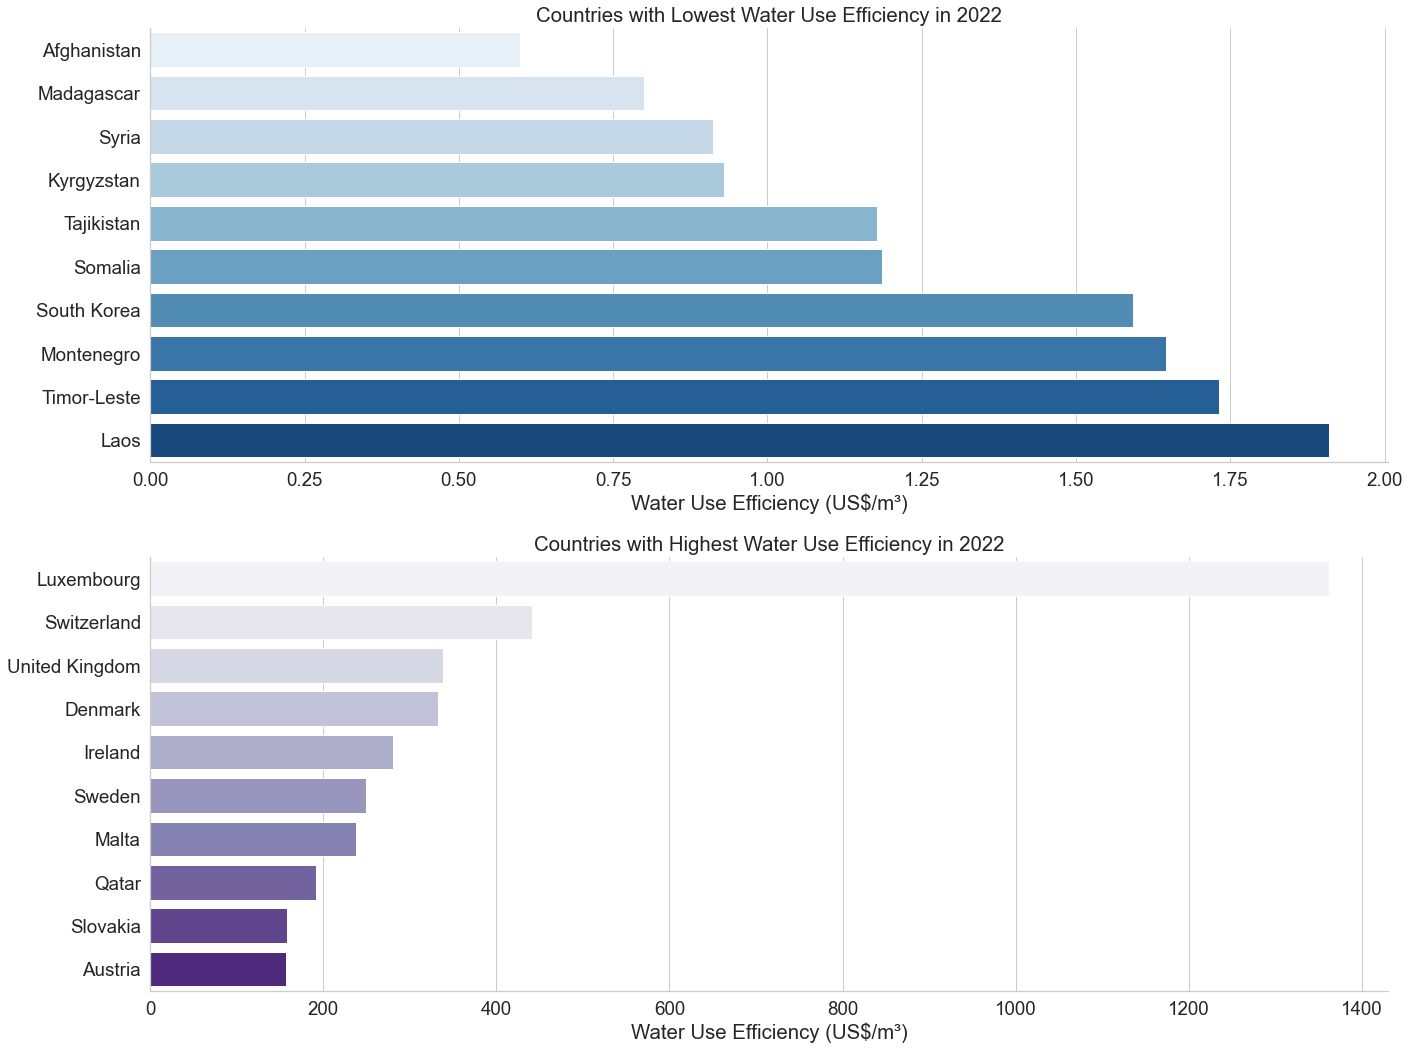

In [456]:
# visualization lowest and highest water use efficiency in 2022 
plt.figure(figsize=(20,15))
wateruse_2022 = df_waterstress_clean[df_waterstress_clean['Year']== 2022][['Area', 'SDG 6.4.1. Water Use Efficiency']
                                ].rename(columns={'SDG 6.4.1. Water Use Efficiency': 'Water Use Efficiency (US$/m³)'})
sns.set_theme(style="whitegrid", font_scale=1.7)

# top10 (excl. from interactive visualization)
plt.subplot(2, 1, 2)
highest10 = wateruse_2022.nlargest(10, 'Water Use Efficiency (US$/m³)')
highest10['Area'] = wateruse_2022['Area'].replace({"United Kingdom of Great Britain and Northern Ireland": 'United Kingdom'}) 
sns.barplot(x='Water Use Efficiency (US$/m³)', y='Area', data=highest10, palette='Purples')
plt.title('Countries with Highest Water Use Efficiency in 2022')
plt.xlabel("Water Use Efficiency (US$/m³)")
plt.ylabel("")
sns.despine()

# bottom 10 
plt.subplot(2, 1, 1)
lowest10 = wateruse_2022.dropna(subset=['Water Use Efficiency (US$/m³)'])
lowest10 = wateruse_2022.nsmallest(10, 'Water Use Efficiency (US$/m³)')
lowest10['Area'] = wateruse_2022['Area'].replace({"Democratic People's Republic of Korea": 'South Korea', 
                                                  "Lao People's Democratic Republic": 'Laos',
                                                  'Syrian Arab Republic': 'Syria',}) 
sns.barplot(x='Water Use Efficiency (US$/m³)', y='Area', data=lowest10, palette='Blues')
plt.title('Countries with Lowest Water Use Efficiency in 2022')
plt.xlabel("Water Use Efficiency (US$/m³)")
plt.ylabel("")
sns.despine()

plt.tight_layout()
plt.savefig('water_efficiency_use_2022.png', dpi=300, bbox_inches='tight')
plt.show()

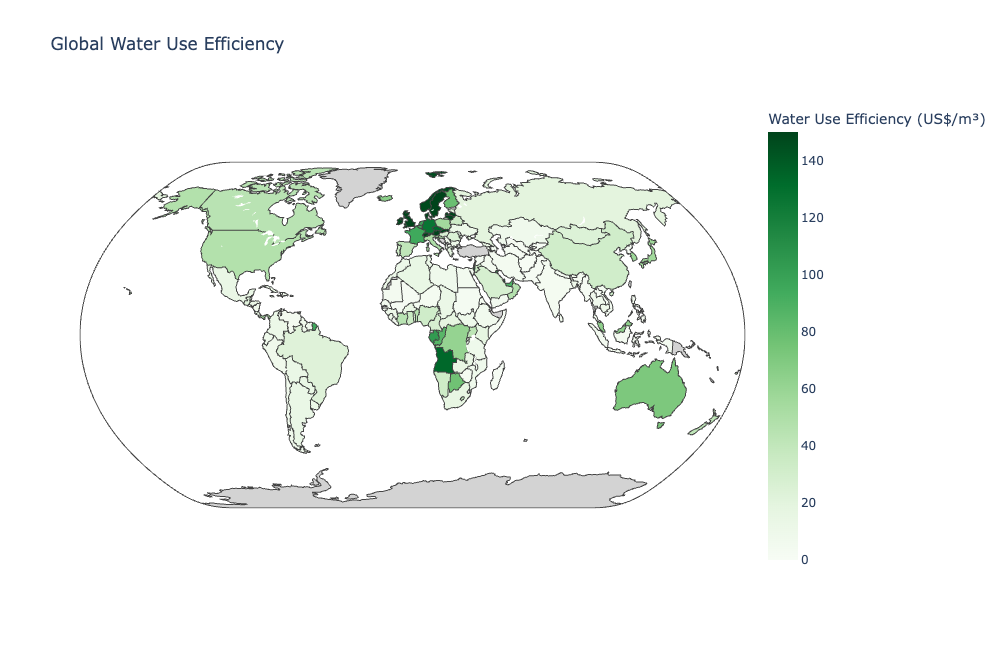

In [457]:
# map Water Use Efficiency
wateruse_2022 = df_waterstress_clean[df_waterstress_clean['Year']== 2022][['Area', 'SDG 6.4.1. Water Use Efficiency']
                                ].rename(columns={'SDG 6.4.1. Water Use Efficiency': 'Water Use Efficiency (US$/m³)'})
    
fig = px.choropleth(
    wateruse_2022,
    locations='Area',
    locationmode='country names',
    color='Water Use Efficiency (US$/m³)',
    hover_name='Area',
    color_continuous_scale='Greens',
    range_color=(0,150),
    title='Global Water Use Efficiency',
    height=650
)

fig.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    showland=True,
    landcolor="LightGray"
)

# Save to interactive HTML and show
fig.write_html("water_use_efficiency_map_2023.html", include_plotlyjs="cdn", full_html=True)
fig.show()
